In [594]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import numerical_quenches as nq 

from numerical_quenches import groundstate

import TFIM_operators_from_states as op

# Goal of Notebook.

Calculate and Plot Entropy.

Calculate Dillute Gas approximation Correction terms.

Use this to understand entropy corrections.

In [595]:
L = 100


In [596]:
Psi_f = groundstate(0,L)

In [597]:

def P_vector(n,states):
    return array([op.Px_n(n,s) for s in states])

def Pz_vector(n,states):
    return array([op.Pz_n(n,s) for s in states])
def g_hold(t,args):
    gf= args
    return gf
def nks(state_initial, state_final):
    ui, vi, _ = state_initial
    uf, vf, _ = state_final

    # This is the amplitude of the 'excited' component
    # equivalent to sin^2(delta_theta / 2)
    nk = np.abs(uf * vi - vf * ui)**2 
    return nk

def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 25*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def entropy_from_nks(nks):
    nks = np.array(nks)
    eps = 1e-15
    nks = np.clip(nks, eps, 1-eps)
    return -np.sum(nks*np.log(nks) + (1-nks)*np.log(1-nks))

In [603]:
taus = np.logspace(-2,2.5,50)
n = 2
n2= 4
n3= 8

In [604]:
def lagrange_multipliers(nks):
    nks = np.array(nks)
    eps = 1e-14
    nks = np.clip(nks, eps, 1-eps)
    lambdas = np.log((1-nks)/nks)
    return lambdas

In [605]:
S=[]
S2=[]
S3=[]
S4= []
LS= []
for tau in taus:
    # Slow Quench 
    L = 300
   # tau = .01
    g0=4
    gf = 0

    psi_0= nq.groundstate(g0,L)
    psi_f = nq.groundstate(gf,L)

    states,time=free_evo_states(tau,gf,g0,L)

    ns = nks(states[-1],psi_f)


    S.append(entropy_from_nks(ns))
    x = array([(2*op.Px_n(n,s)) for s in states[-20:] ])
    y = array([(2*op.Px_n(n2,s)) for s in states[-20:] ])
    z= array([(2*op.Px_n(n3,s)) for s in states[-20:] ])
    x= np.average(x)
    y = np.average(y)
    S2.append(-log(x))
    S3.append(-log(y))
    S4.append(-log(z))

    LS.append(lagrange_multipliers(ns))

S=array(S)
S2 = array(S2)
S3= array(S3)

g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0


In [617]:
gfs = [0, 0.25]
ns_list = [2,3,4,5,6,7,8]

results = {}

for gf in gfs:

    S  = []
    Pn = {n: [] for n in ns_list}
    LS = []

    for tau in tqdm(taus):

        L  = 300
        g0 = 4

        psi_0 = nq.groundstate(g0, L)
        psi_f = nq.groundstate(gf, L)

        states, time = free_evo_states(tau, gf, g0, L)

        nk_vals = nks(states[-1], psi_f)
        S.append(entropy_from_nks(nk_vals))

        for n in ns_list:
            vals = np.array([(op.Px_n(n, s)) for s in states[-20:]])
            Pn[n].append(np.mean(vals))

        LS.append(lagrange_multipliers(nk_vals))

    results[gf] = {
        "S": np.array(S),
        "Pn": {n: np.array(Pn[n]) for n in ns_list},
        "LS": LS
    }

  0%|          | 0/50 [00:00<?, ?it/s]

g0=1.0
g0=0.0


  2%|▏         | 1/50 [00:03<02:29,  3.06s/it]

g0=1.0
g0=0.0


  4%|▍         | 2/50 [00:05<02:01,  2.52s/it]

...

 96%|█████████▌| 48/50 [02:06<00:09,  4.63s/it]

g0=1.0
g0=0.25


 98%|█████████▊| 49/50 [02:13<00:05,  5.23s/it]

g0=1.0
g0=0.25


100%|██████████| 50/50 [02:20<00:00,  2.81s/it]


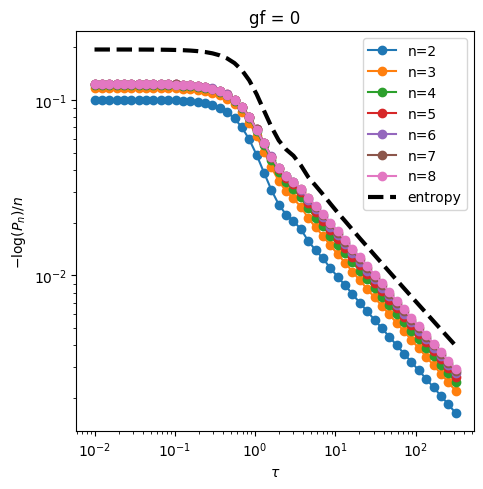

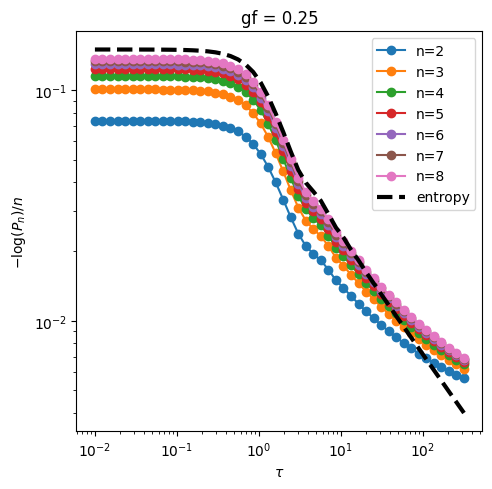

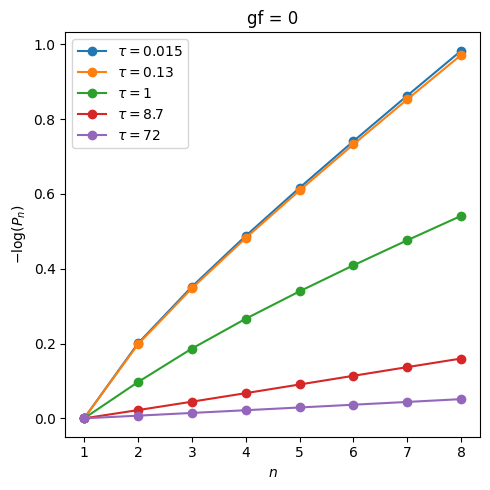

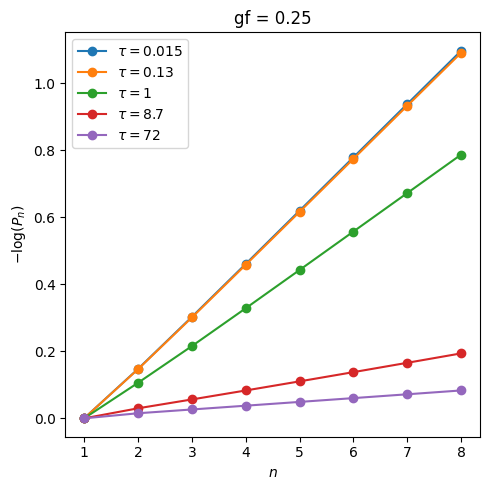

In [630]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1)  -log(Pn)/n  and entropy vs tau
# -----------------------------
for gf in gfs:

    plt.figure(figsize=(5,5))

    for n in ns_list:
        y = -np.log(2*results[gf]["Pn"][n]) / n
        plt.plot(taus, y, "o-", label=f"n={n}")

    plt.plot(taus, results[gf]["S"]/L, "--k", lw=3, label="entropy")

    plt.xlabel(r"$\tau$")
    plt.ylabel(r"$-\log(P_n)/n$")
    plt.title(f"gf = {gf}")
    plt.legend()
    plt.xscale("log")
    plt.tight_layout()
    loglog()
    plt.show()


# -----------------------------
# 2)  -log(Pn) vs n  (each tau)
# -----------------------------
for gf in gfs:

    plt.figure(figsize=(5,5))

    for i, tau in enumerate(taus):
        if i%10!=2:
            pass
        else:
            y = [0]+[-np.log(2*results[gf]["Pn"][n][i]) for n in ns_list]
            plt.plot([1]+ns_list, y, "o-", label=rf"$\tau={tau:.2g}$")

    plt.xlabel(r"$n$")
    plt.ylabel(r"$-\log(P_n)$")
    plt.title(f"gf = {gf}")
    plt.legend()
    plt.tight_layout()
    plt.show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


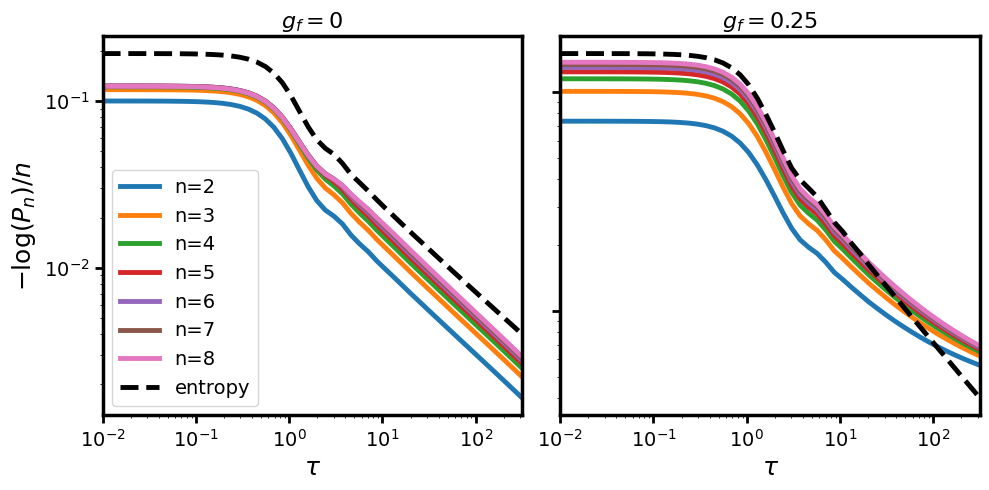

In [653]:
import matplotlib.pyplot as plt
import numpy as np

# =================================================
# STYLE / USER CONTROLS
# =================================================
LW        = 3.5
BORDER_LW = 2.5
TICK_W    = 2
TICK_L    = 6

FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 14

FIG_W = 10
FIG_H = 5

TAU_STRIDE = 10      # spacing between tau curves
LOG_P_FACTOR = 2     # multiplies Pn before log
USE_LOGLOG = True

# =================================================
# FIGURE 1
#   -log(Pn)/n  and entropy vs tau
# =================================================
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

for ax, gf in zip(axes, gfs):

    for n in ns_list:
        y = -np.log(LOG_P_FACTOR * results[gf]["Pn"][n]) / n
        ax.plot(taus, y, lw=LW, label=f"n={n}")

    ax.plot(
        taus,
        results[gf]["S"]/L,
        "--k",
        lw=LW,
        label="entropy"
    )

    ax.set_xlabel(r"$\tau$", fontsize=FS_LABEL)
    ax.set_ylabel(r"$-\log(P_n)/n$", fontsize=FS_LABEL)
    ax.set_title(rf"$g_f={gf}$", fontsize=FS_TITLE)

    if USE_LOGLOG:
        ax.set_xscale("log")
        ax.set_yscale("log")

axes[0].legend(fontsize=FS_LEGEND)
axes[1].set_yticklabels("")
# styling
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(BORDER_LW)
    ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)
    ax.set_xlim(taus[0],taus[-1])

axes[1].set_ylabel("")
plt.tight_layout()
plt.show()




/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


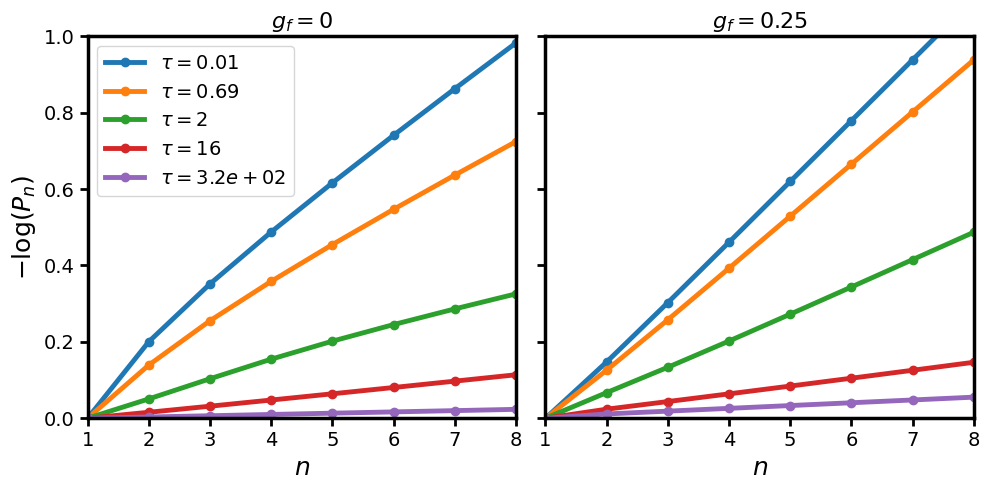

In [652]:
# =================================================
# FIGURE 2
#   -log(Pn) vs n
# =================================================

TAU_SELECT = [0, 20, 25, 35,49]   # indices of taus you want to plot
# or directly: TAU_SELECT = [10, 50, 200]

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

for ax, gf in zip(axes, gfs):

    for i in TAU_SELECT:

        tau = taus[i]

        y = [0] + [-np.log(LOG_P_FACTOR * results[gf]["Pn"][n][i]) for n in ns_list]
        x = [1] + ns_list

        ax.plot(x, y, "o-", lw=LW, label=rf"$\tau={tau:.2g}$")

    ax.set_xlabel(r"$n$", fontsize=FS_LABEL)
    ax.set_title(rf"$g_f={gf}$", fontsize=FS_TITLE)
    ax.set_xlim(1,8)
    ax.set_ylim(0,1)
axes[0].set_ylabel(r"$-\log(P_n)$", fontsize=FS_LABEL)
axes[1].set_yticklabels("")
axes[0].legend(fontsize=FS_LEGEND)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(BORDER_LW)
    ax.tick_params(width=TICK_W, length=TICK_L, labelsize=FS_TICK)

plt.tight_layout()
plt.show()

[]

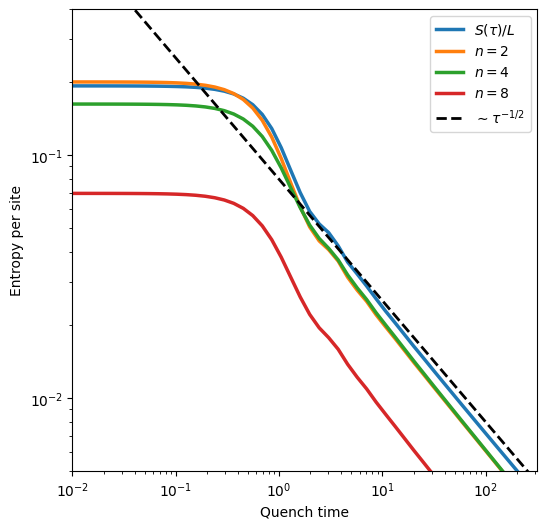

In [615]:
plt.figure(figsize=(6,6))
plot((taus), S/(L), label=r"$S(\tau)/L$",lw=2.5)
plot((taus), S2/(n-1)+0/sqrt(taus*2)/8/pi, label=rf"$n={n}$",lw=2.5)
plot((taus), S3/(n2-1)+0/sqrt(taus*2)/8/pi, label=rf"$n={n2}$",lw=2.5)
plot((taus), S3/(n3-1)+0/sqrt(taus*2)/8/pi, label=rf"$n={n3}$",lw=2.5)

plot((taus), 1/(4*pi*np.sqrt(taus)), "--k", label=r"$\sim \tau^{-1/2}$",lw=2)

#title(f"Entropy vs Quench Time, $g_f={gf}$")
xlabel("Quench time")
ylabel("Entropy per site")

xlim(taus[0], taus[-1])
ylim(0.005, 0.4)

legend()
loglog()

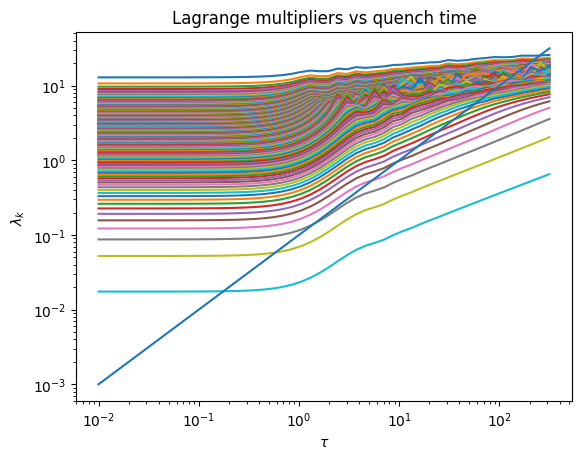

In [324]:
LS = np.array(LS)      # shape: (len(taus), N_k)

plt.figure()

for k in range(LS.shape[1]):
    plt.plot(taus, LS[:,k])

plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\lambda_k$")
plt.title("Lagrange multipliers vs quench time")
plot(taus,taus**(1)/10)
loglog()
plt.show()


In [325]:

from scipy.optimize import brentq
TS = []
S  = []
S2 = []
S3 = []
LS = []

for tau in taus:
    L  = 50
    g0 = 4
    gf = 0.5

    psi_0 = nq.groundstate(g0, L)
    psi_f = nq.groundstate(gf, L)

    states, time = free_evo_states(tau, gf, g0, L)

    ns = nks(states[-1], psi_f)

    ks  = np.pi * (2*np.arange(L//2) + 1) / L
    eps = 2*np.sqrt(1 + gf**2 - 2*gf*np.cos(ks))

    E_post = np.sum(eps * ns)

    def E_T(T):
        return np.sum(eps / (np.exp(eps / T) + 1))

    T_eff = brentq(lambda T: E_T(T) - E_post, 1e-8, 100)
    TS.append(T_eff)

    S.append(entropy_from_nks(ns))

    x = np.array([2 * op.Px_n(n,  s) for s in states[-20:]])
    y = np.array([2 * op.Px_n(n2, s) for s in states[-20:]])
    x = np.average(x)
    y = np.average(y)

    S2.append(-np.log(x))
    S3.append(-np.log(y))
    LS.append(lagrange_multipliers(ns))

TS = np.array(TS)
S  = np.array(S)
S2 = np.array(S2)
S3 = np.array(S3)

g0=1.0
g0=0.5


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/803401805.py:26: RuntimeWarning: overflow encountered in exp
  return np.sum(eps / (np.exp(eps / T) + 1))


g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5
g0=1.0
g0=0.5


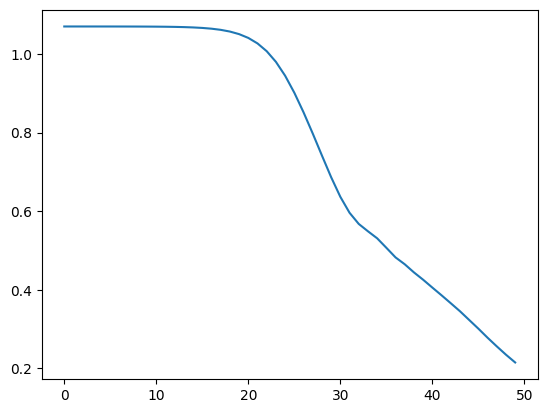

In [326]:
plot(TS)

# Very little abvoe this actually matters

Goal: Find out Xi_KZ exactly.

In [342]:
gs =np.linspace(0,1,100)

In [343]:
ns = array([2,3,4,5,6,7])
dat=[]
for g in gs:
    psi = nq.groundstate(g,200)
    P = array([op.Px_n(n,psi) for n in ns])
    dat.append(P)

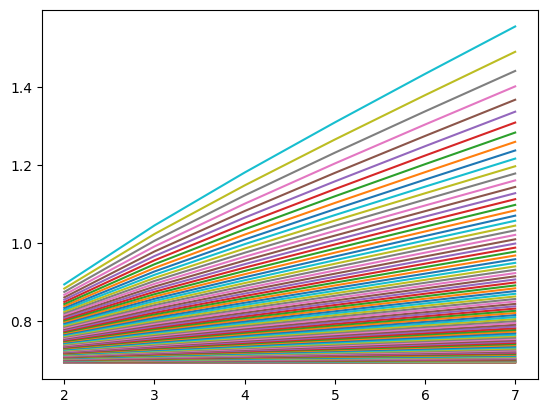

In [344]:
for d in dat:
    plot(ns,-log(d))




/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/2140060149.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.plot(gs, 1/slopes, "o-")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/2140060149.py:17: RuntimeWarning: invalid value encountered in divide
  plt.plot(gs, 1/slopes, "o-")
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/2140060149.py:18: RuntimeWarning: divide by zero encountered in power
  plot(gs,gs**(-2)*16,label= r"$\frac{16}{g^2}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/21400

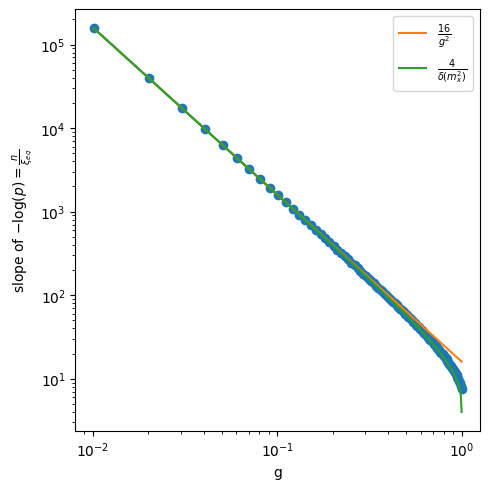

In [374]:
import numpy as np
from numpy import log
from scipy.stats import linregress
import matplotlib.pyplot as plt

slopes = []

for d in dat:
    y = -np.log(d)
    slope, intercept, r, p, se = linregress(ns, y)
    slopes.append(slope)

slopes = np.array(slopes)

plt.figure(figsize=(5,5))
loglog()
plt.plot(gs, 1/slopes, "o-")
plot(gs,gs**(-2)*16,label= r"$\frac{16}{g^2}$")
plot(gs, 4/(-(1-gs**2)**(1/4)+1),label= r"$\frac{4}{\delta(m_x^2)}$")
plt.xlabel("g")
legend()
plt.ylabel(r"slope of $-\log(p) =  \frac{n}{\xi_{eq}}$")
plt.tight_layout()
plt.show()

In [377]:
import kblock_ising_model as kb 
ks = kb.k_vals(100)
gs = linspace(0,1,100)


states = [kb.U(ks,g) for g in gs]

import analytical_quench_states as kz
taus =  logspace(2,3,4)
states= [kz.state(L,tau,tau) for tau in taus]
P = [[op.Px_n(n,s) for n in ns] for s in states]
P_f = array(P)

plot(ns,-log(P_f).T,label=taus)
legend()


In [ ]:
import analytical_quench_states as kz
taus =  logspace(1.5,3,4)
ns = [2,3,4,5,6,7]
gf = [0 , 0.1,0.25,0.5,0.75]
states= [ [kz.state(L,tau,tau*(1-g)) for tau in taus] for g in gf]




In [429]:
import numpy as np

taus = logspace(1.5,3,4)
ns   = array([2,3,4,5,6,7])
gfs  = [0 , 0.1,0.25,0.5,0.75]

# states[g_index][tau_index]
states = [[kz.state(L, tau, tau*(1-g)) for tau in taus] for g in gfs]

# result[g_index, tau_index, n_index]
P = np.zeros((len(gfs), len(taus), len(ns)))

for gi, g in enumerate(gfs):
    for ti, tau in enumerate(taus):
        state = states[gi][ti]
        for ni, n in enumerate(ns):
            P[gi, ti, ni] = op.Px_n(n, state)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/3437494765.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  P[gi, ti, ni] = op.Px_n(n, state)


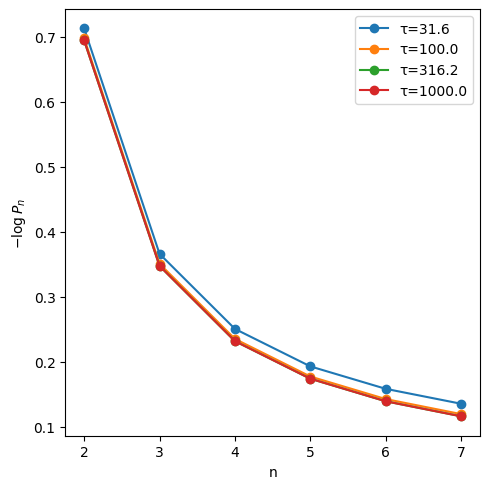

In [465]:
import numpy as np
import matplotlib.pyplot as plt

taus = np.logspace(1.5,3,4)
ns   = np.array([2,3,4,5,6,7])

g = 0.1  # choose the g you want

alpha = 4
beta  = 1
power = 0.5

def xi1(g):
    return alpha / (1 - (1 - g**2)**0.25)

def xi2(tau):
    return beta * tau**power

plt.figure(figsize=(5,5))

for tau in taus:

    state = kz.state(L, tau, tau*(1-g))
    Pn = np.array([op.Px_n(n, state) for n in ns])

    y = -np.log(Pn)/(ns-1)
    x = ns 

    plt.plot(ns, y, "o-", label=f"τ={tau:.1f}")

plt.xlabel("n")
plt.ylabel(r"$-\log P_n$")
plt.legend()
plt.tight_layout()
plt.show()




In [555]:
from numpy import exp as exp

exp(2)

np.float64(7.38905609893065)

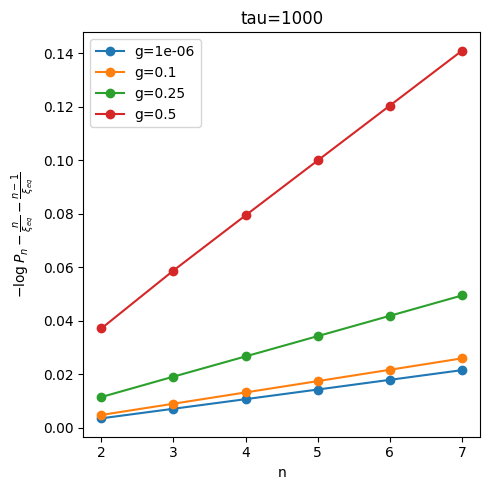

In [572]:
import numpy as np
import matplotlib.pyplot as plt

taus = np.logspace(1.5,3,4)
ns   = np.array([2,3,4,5,6,7])
gfs  = np.array([0.000001 , 0.1,0.25,0.5])

tau = 1000   # choose the tau you want

plt.figure(figsize=(5,5))
L = 500
for g in gfs:

    state = kz.state(L, tau, tau*(1-g))
    Pn = np.array([op.Px_n(n, state) for n in ns])
    mx2= 1- (1-g*g)**(1/4)
    xi_kz = 2*pi*sqrt(2*tau)

    y= -log(2*Pn)
    xi_eq = 4/(1-(1-g*g)**(1/4))
    expon = (ns)/xi_eq
    f= +expon+(ns-1)/xi_kz
    plt.plot(ns, y,  "o-", label=f"g={g}")
#ylim(-.1,.1)
title(f"tau={tau}")
plt.xlabel("n")
plt.ylabel(r"$-\log P_n - \frac{n}{\xi_{eq}}- \frac{n-1}{\xi_{eq}}$")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_49199/2225428703.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  return alpha / (1 - (1 - g**2)**0.25)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


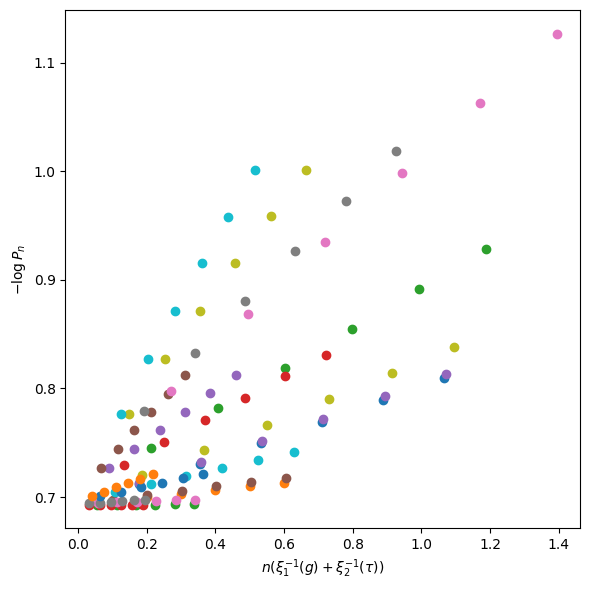

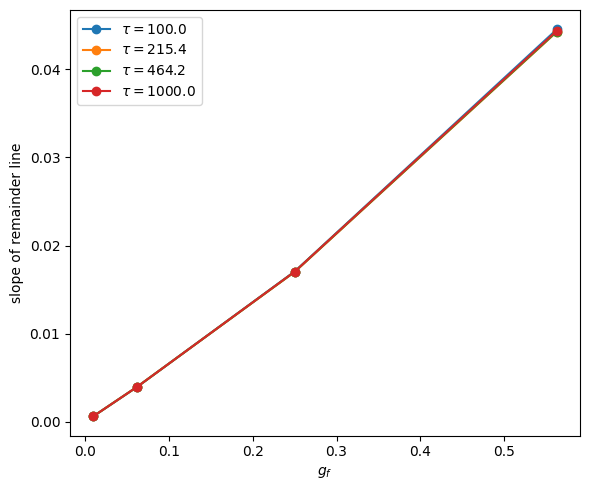

In [316]:

# --------- plot extracted slope vs gf ----------
plt.figure(figsize=(6, 5))

for tau in taus:
    plt.plot(gfs[1:]**2, slope_dat[tau], "o-", label=fr"$\tau={tau:.1f}$")

plt.xlabel(r"$g_f$")
plt.ylabel(r"slope of remainder line")
plt.tight_layout()
plt.legend()
plt.show()

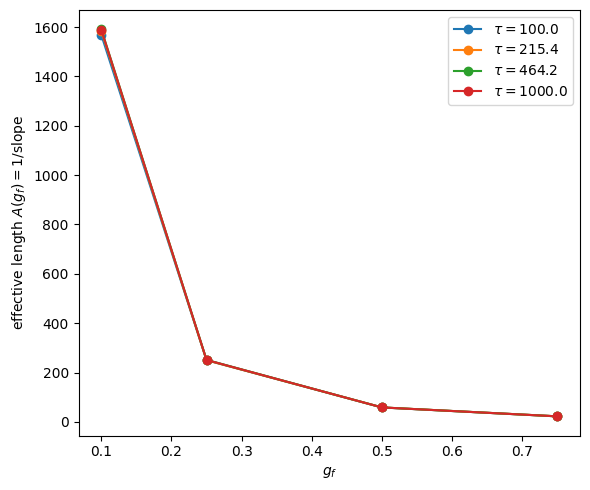

In [312]:
plt.figure(figsize=(6, 5))

for tau in taus:
    slopes = np.array(slope_dat[tau])
    plt.plot(gfs[1:], 1/slopes, "o-", label=fr"$\tau={tau:.1f}$")

plt.xlabel(r"$g_f$")
plt.ylabel(r"effective length $A(g_f)=1/\mathrm{slope}$")
plt.tight_layout()
plt.legend()
plt.show()